In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import os

In [ ]:
#Load the meetings dataset
calls_df = pd.read_csv('../data/raw/Montagna_Phone_Calls_Edgelist.csv')
print(calls_df.shape)
print(calls_df.columns)
calls_df.head()

(150, 3)
Index(['Source', 'Target', 'Weight'], dtype='str')


,Source,Target,Weight
0,N14,N101,2
1,N18,N19,5
2,N19,N18,6
3,N102,N18,1
4,N32,N18,1


In [5]:
# Make column names lowercase
calls_df.columns = calls_df.columns.str.lower()

In [6]:
calls_df.head()

,source,target,weight
0,N14,N101,2
1,N18,N19,5
2,N19,N18,6
3,N102,N18,1
4,N32,N18,1


In [7]:
nodes = pd.unique(calls_df[['source', 'target']].values.ravel())

node_mapping = {node: i for i, node in enumerate(nodes)}

calls_df['source_id'] = calls_df['source'].map(node_mapping)
calls_df['target_id'] = calls_df['target'].map(node_mapping)

In [8]:
G = ig.Graph.DataFrame(calls_df[['source_id', 'target_id', 'weight']], directed=False)
layout = 'fr'
print(G.summary())

IGRAPH U-W- 95 150 -- 
+ attr: weight (e)


In [9]:
edge_widths = [w * 0.1 for w in G.es['weight']]

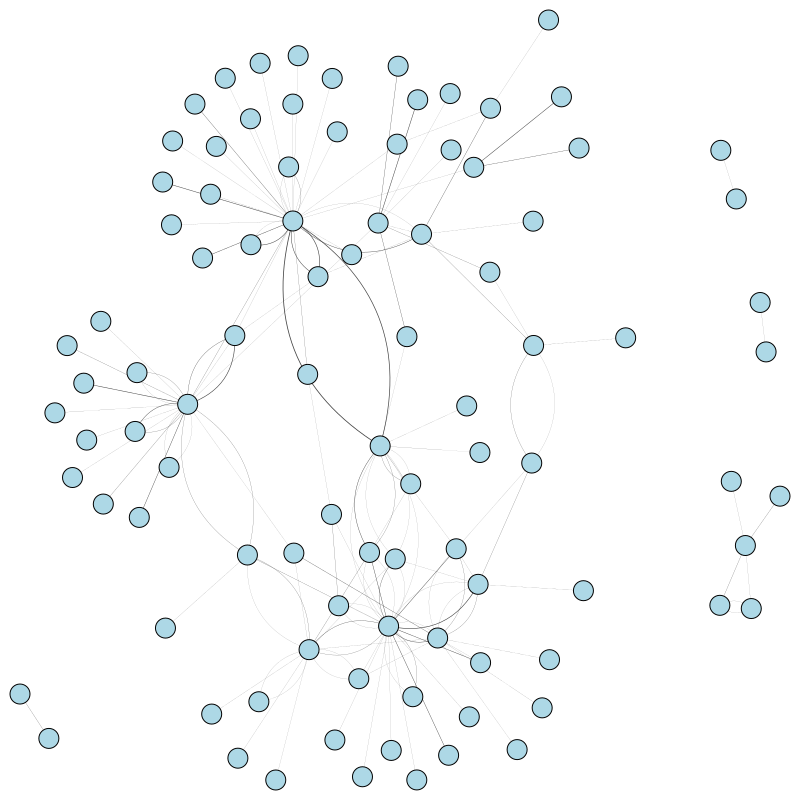

In [10]:
ig.plot(
    G,
    vertex_size=20,
    vertex_color='lightblue',
    edge_width=[w * 0.1 for w in G.es['weight']],
    layout='fr',
    bbox=(800, 800)
)

In [12]:
# Get centrality measures
degrees = G.degree()
betweenness = G.betweenness()
closeness = G.closeness()

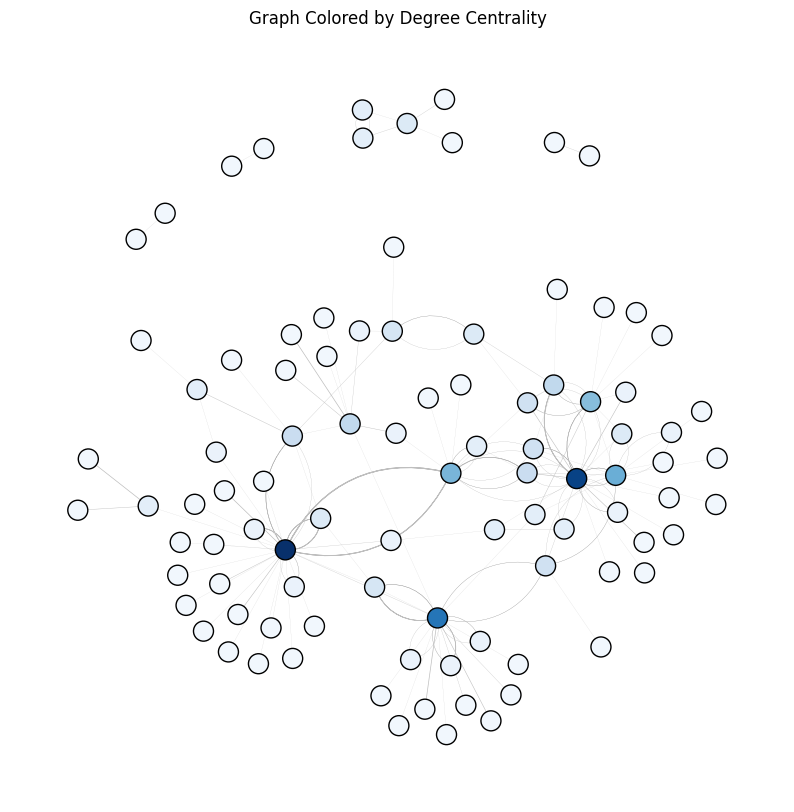

In [13]:
# Color nodes by degree
degree_colors = [plt.cm.Blues(deg / max(degrees)) for deg in degrees]

# Visualize the graph with degree-based coloring
fig, ax = plt.subplots(figsize=(10, 10))

ig.plot(
    G,
    target=ax,
    layout=layout,
    vertex_size=20,
    vertex_color=degree_colors,
    edge_width=edge_widths,
    edge_color='gray',
    vertex_label_size=8,
)

ax.set_title('Graph Colored by Degree Centrality')
plt.show()